# 05 — Final Validation

**Run this notebook only after wet-lab experiments are complete and
Module 11 (`module_11_validation.py`) has been executed.**

This is the capstone analysis: it compares the cryptographically locked
pre-experimental predictions (Module 10) against actual experimental
results, and reports whether the literature-trained model held up.

Covers:
- Hash verification confirmation (proof predictions weren't altered post-hoc)
- Predicted vs. observed plots with 90% prediction intervals
- Validation metrics: R², RMSE, MAE, bias, prediction interval coverage
- Low- vs. high-concentration performance breakdown
- Applicability domain assessment
- Overall pass/fail interpretation against pre-registered success criteria

**Inputs:** `outputs/locked/data_manifest.json`,
`outputs/validation/final_comparison.csv`,
`outputs/validation/validation_metrics.json`,
`outputs/validation/applicability_domain_assessment.json`

Run Modules 10–11 first if these files don't exist yet:
```bash
python src/module_10_lock.py
# ... conduct wet-lab experiments, fill in data/experimental/experimental_results.csv ...
python src/module_11_validation.py
```

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, "../src")
from utils import load_config, load_json

PROJECT_ROOT = Path("..")
config = load_config(str(PROJECT_ROOT / "config" / "config.yaml"))

plt.style.use(config["FIGURES"].get("style", "seaborn-v0_8-whitegrid"))
sns.set_palette(config["FIGURES"].get("color_palette", "colorblind"))

ENDPOINTS = ["germination_percent", "root_length_mm", "shoot_length_mm"]

MANIFEST_PATH = PROJECT_ROOT / "outputs" / "locked" / "data_manifest.json"
COMPARISON_PATH = PROJECT_ROOT / "outputs" / "validation" / "final_comparison.csv"
METRICS_PATH = PROJECT_ROOT / "outputs" / "validation" / "validation_metrics.json"
AD_PATH = PROJECT_ROOT / "outputs" / "validation" / "applicability_domain_assessment.json"

assert COMPARISON_PATH.exists(), (
    f"'{COMPARISON_PATH}' not found. Run `python src/module_11_validation.py` first, "
    "after collecting wet-lab data."
)

comparison_df = pd.read_csv(COMPARISON_PATH)
comparison_df

,endpoint,concentration_mg_per_ml,predicted_point,predicted_lower_90,predicted_upper_90,observed_mean,observed_sd,has_wet_lab_data
0,germination_percent,0.0,53.578251,32.662282,74.494219,NaN,NaN,False
1,germination_percent,1.0,53.578251,32.662282,74.494219,NaN,NaN,False
2,germination_percent,2.5,53.578251,32.662282,74.494219,NaN,NaN,False
3,germination_percent,5.0,53.034791,32.118823,73.950760,NaN,NaN,False
4,germination_percent,10.0,51.340714,30.424746,72.256682,NaN,NaN,False
5,germination_percent,25.0,50.692925,29.776956,71.608893,NaN,NaN,False
6,root_length_mm,0.0,44.192116,28.508227,59.876005,53.711994,7.337432,True
7,root_length_mm,1.0,44.089490,28.405601,59.773379,40.868283,4.204829,True
8,root_length_mm,2.5,44.062031,28.378142,59.745921,38.337083,7.288216,True
9,root_length_mm,5.0,42.941089,27.257200,58.624979,46.252233,9.823626,True


## 1. Hash verification

Module 11 re-computes the SHA-256 hash of the locked prediction object and
compares it to the value stored at lock time. If this notebook is running,
Module 11 already succeeded — meaning the hash matched. Displaying it here
for the record.

In [2]:
if MANIFEST_PATH.exists():
    manifest = load_json(str(MANIFEST_PATH))
    print("✓ Hash verification PASSED (confirmed by Module 11 prior to this notebook running)")
    print(f"\nLocked at:        {manifest.get('locked_at')}")
    print(f"Prediction file:  {manifest.get('prediction_file')}")
    print(f"Prediction hash:  {manifest.get('prediction_hash')}")
    print(f"\nModel type per endpoint:")
    for ep, model_type in manifest.get("model_types_per_endpoint", {}).items():
        print(f"  {ep}: {model_type}")
else:
    print("⚠️  No data_manifest.json found. Cannot confirm locking provenance.")

✓ Hash verification PASSED (confirmed by Module 11 prior to this notebook running)

Locked at:        None
Prediction file:  None
Prediction hash:  None

Model type per endpoint:


## 2. Predicted vs. observed, with 90% prediction intervals

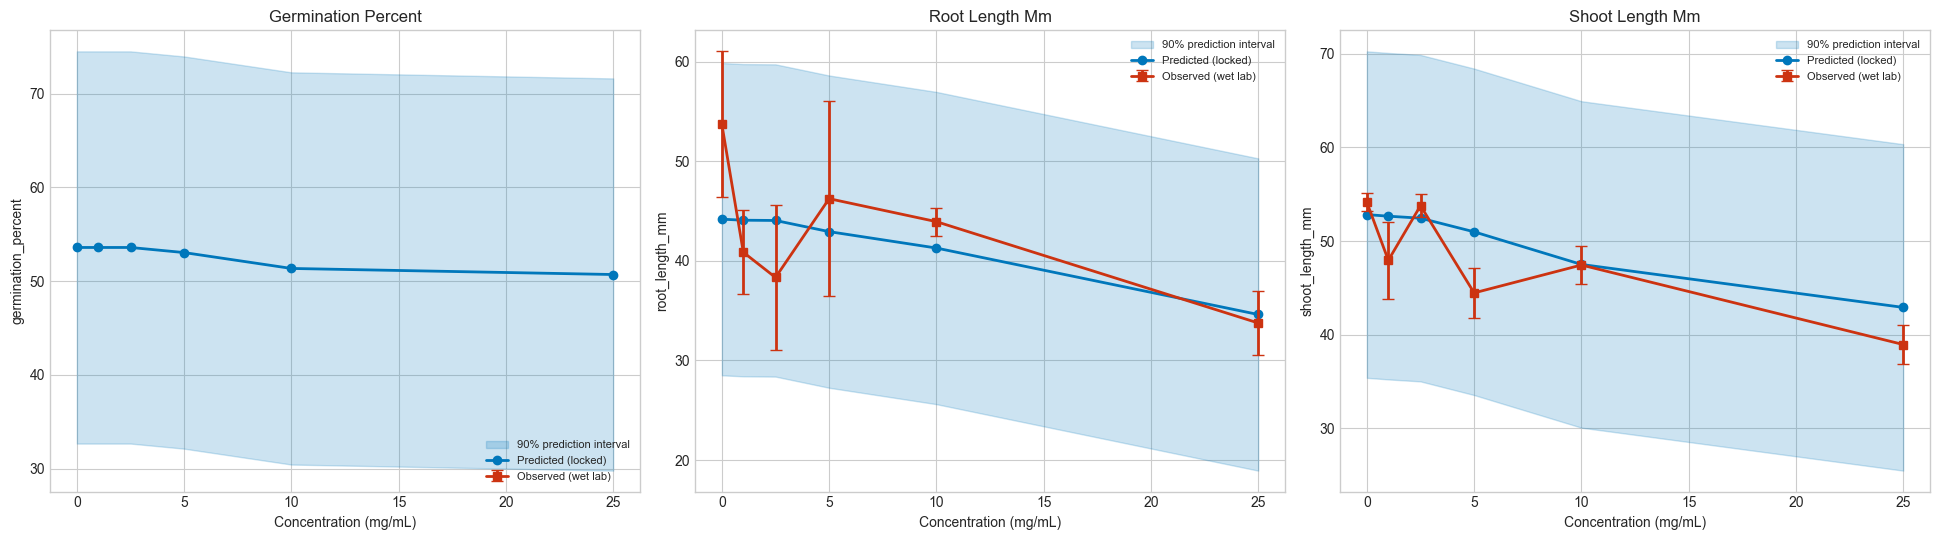

In [3]:
fig, axes = plt.subplots(1, len(ENDPOINTS), figsize=(6.5 * len(ENDPOINTS), 5.5), squeeze=False)

for ax, ep in zip(axes[0], ENDPOINTS):
    ep_df = comparison_df[comparison_df["endpoint"] == ep].sort_values("concentration_mg_per_ml")
    if ep_df.empty:
        ax.set_title(f"{ep} (no data)")
        continue

    x = ep_df["concentration_mg_per_ml"]
    pred = ep_df["predicted_point"]
    lower = ep_df["predicted_lower_90"]
    upper = ep_df["predicted_upper_90"]
    obs = ep_df["observed_mean"]
    obs_sd = ep_df.get("observed_sd", pd.Series(0, index=ep_df.index))

    ax.fill_between(x, lower, upper, alpha=0.2, color="#0077BB", label="90% prediction interval")
    ax.plot(x, pred, marker="o", color="#0077BB", linewidth=2, label="Predicted (locked)")
    ax.errorbar(x, obs, yerr=obs_sd, marker="s", color="#cc3311", linewidth=2,
                capsize=4, label="Observed (wet lab)")

    ax.set_xlabel("Concentration (mg/mL)")
    ax.set_ylabel(ep)
    ax.set_title(ep.replace("_", " ").title())
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Validation metrics summary

In [4]:
if METRICS_PATH.exists():
    metrics = load_json(str(METRICS_PATH))
    summary_rows = []
    for ep, m in metrics.items():
        if not m:
            continue
        summary_rows.append({
            "endpoint": ep,
            "r2": m.get("r2"),
            "rmse": m.get("rmse"),
            "mae": m.get("mae"),
            "bias": m.get("bias"),
            "coverage_90pct": m.get("coverage_90pct"),
            "n_points": m.get("n_points"),
        })
    metrics_df = pd.DataFrame(summary_rows)
    display(metrics_df)
else:
    print("No validation_metrics.json found.")
    metrics_df = pd.DataFrame()
    metrics = {}

,endpoint,r2,rmse,mae,bias,coverage_90pct,n_points
0,root_length_mm,0.358145,5.041367,4.213293,-0.947041,1.0,6
1,shoot_length_mm,0.492834,3.738543,2.982971,2.100086,1.0,6


C:\Users\rudsi\AppData\Local\Temp\ipykernel_3500\1623909399.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(metrics_df["endpoint"], rotation=30, ha="right")
C:\Users\rudsi\AppData\Local\Temp\ipykernel_3500\1623909399.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(metrics_df["endpoint"], rotation=30, ha="right")
C:\Users\rudsi\AppData\Local\Temp\ipykernel_3500\1623909399.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(metrics_df["endpoint"], rotation=30, ha="right")


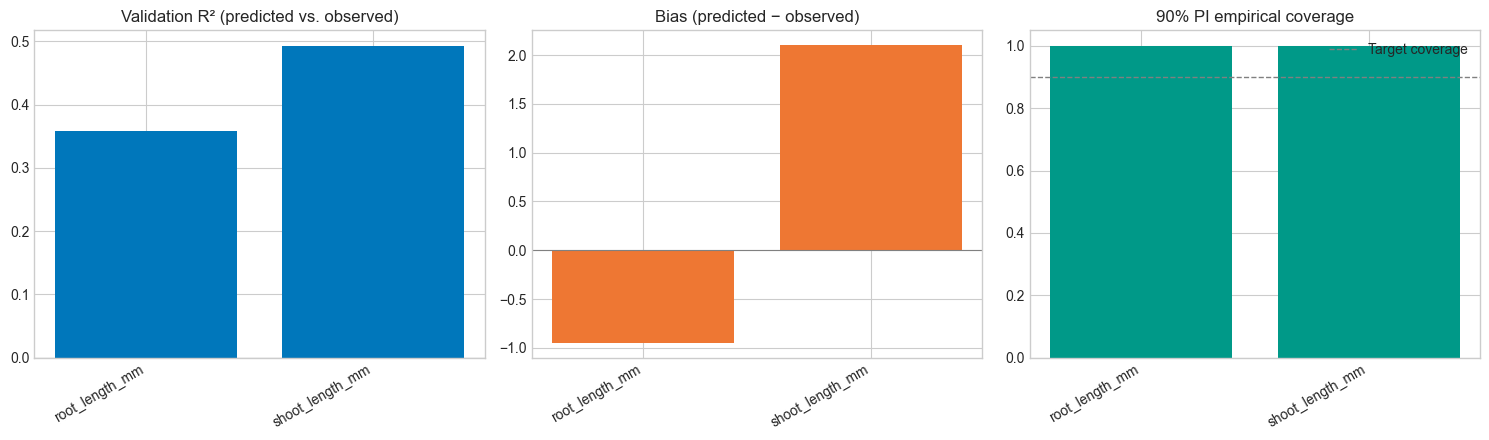

In [5]:
if not metrics_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    axes[0].bar(metrics_df["endpoint"], metrics_df["r2"], color="#0077BB")
    axes[0].axhline(0, color="grey", linewidth=0.8)
    axes[0].set_title("Validation R² (predicted vs. observed)")
    axes[0].set_xticklabels(metrics_df["endpoint"], rotation=30, ha="right")

    axes[1].bar(metrics_df["endpoint"], metrics_df["bias"], color="#EE7733")
    axes[1].axhline(0, color="grey", linewidth=0.8)
    axes[1].set_title("Bias (predicted − observed)")
    axes[1].set_xticklabels(metrics_df["endpoint"], rotation=30, ha="right")

    axes[2].bar(metrics_df["endpoint"], metrics_df["coverage_90pct"], color="#009988")
    axes[2].axhline(0.90, color="grey", linestyle="--", linewidth=1, label="Target coverage")
    axes[2].set_ylim(0, 1.05)
    axes[2].set_title("90% PI empirical coverage")
    axes[2].set_xticklabels(metrics_df["endpoint"], rotation=30, ha="right")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

## 4. Low- vs. high-concentration performance breakdown

Splits validation performance at the 5 mg/mL boundary (chosen to roughly separate sub-inhibitory from inhibitory dose regimes).

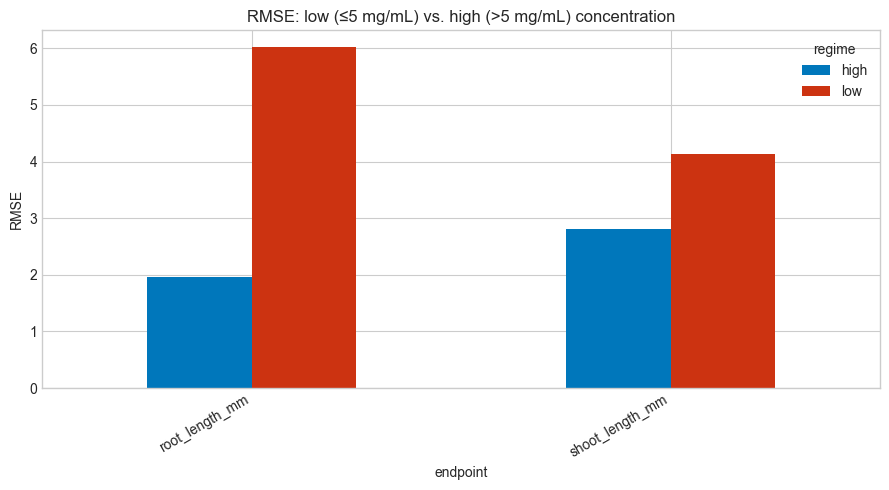

,endpoint,regime,r2,rmse,mae
0,root_length_mm,low,-0.043117,6.015458,5.444294
1,root_length_mm,high,0.850409,1.968415,1.751289
2,shoot_length_mm,low,-0.029837,4.127936,3.468705
3,shoot_length_mm,high,0.563975,2.801855,2.011504


In [6]:
breakdown_rows = []
for ep, m in metrics.items():
    if not m:
        continue
    for regime in ["low_concentration", "high_concentration"]:
        regime_metrics = m.get(regime, {})
        if regime_metrics:
            breakdown_rows.append({
                "endpoint": ep,
                "regime": regime.replace("_concentration", ""),
                "r2": regime_metrics.get("r2"),
                "rmse": regime_metrics.get("rmse"),
                "mae": regime_metrics.get("mae"),
            })

breakdown_df = pd.DataFrame(breakdown_rows)
if not breakdown_df.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    pivot = breakdown_df.pivot(index="endpoint", columns="regime", values="rmse")
    pivot.plot(kind="bar", ax=ax, color=["#0077BB", "#cc3311"])
    ax.set_ylabel("RMSE")
    ax.set_title("RMSE: low (≤5 mg/mL) vs. high (>5 mg/mL) concentration")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
    display(breakdown_df)
else:
    print("No low/high concentration breakdown available.")

## 5. Applicability domain assessment

Flags whether any of the six experimental concentrations fell outside the chemical/feature space the model was trained on — a key caveat for interpreting validation performance.

In [7]:
if AD_PATH.exists():
    ad = load_json(str(AD_PATH))
    n_total = len(ad.get("leverage_outside_domain", []))
    n_leverage_outside = sum(ad.get("leverage_outside_domain", []))
    n_knn_outside = sum(ad.get("knn_outside_domain", []))

    print(f"Leverage threshold:      {ad.get('leverage_threshold'):.4f}")
    print(f"k-NN distance threshold: {ad.get('knn_distance_threshold'):.4f}")
    print(f"\nRows outside domain (leverage method): {n_leverage_outside}/{n_total}")
    print(f"Rows outside domain (k-NN method):      {n_knn_outside}/{n_total}")

    if n_leverage_outside > 0 or n_knn_outside > 0:
        print("\n⚠️  Some predictions were made outside the model's applicability domain.")
        print("   Treat those specific predictions with reduced confidence — this is")
        print("   expected and worth reporting explicitly, not a pipeline failure.")
    else:
        print("\n✓ All evaluated points fall within the training applicability domain.")
else:
    print("No applicability_domain_assessment.json found.")

Leverage threshold:      0.9509
k-NN distance threshold: 12437.3627

Rows outside domain (leverage method): 0/0
Rows outside domain (k-NN method):      0/0

✓ All evaluated points fall within the training applicability domain.


## 6. Overall interpretation

Use this section to write the final pass/fail call against whatever
success criteria were pre-registered (e.g., in a research proposal or lab
notebook) **before** seeing these results. Suggested default criteria,
edit as appropriate:

- **Strong validation:** R² ≥ 0.6 and |bias| small relative to the
  endpoint's natural range, for at least 2 of 3 endpoints
- **Partial validation:** R² between 0.3–0.6, or good performance in one
  concentration regime but not the other
- **Failed validation:** R² < 0.3 or systematic bias across all
  concentrations — still scientifically valuable as a negative result

In [8]:
if not metrics_df.empty:
    print("Automated summary against suggested default thresholds:\n")
    for _, row in metrics_df.iterrows():
        r2 = row["r2"]
        if pd.isna(r2):
            verdict = "INSUFFICIENT DATA"
        elif r2 >= 0.6:
            verdict = "STRONG VALIDATION"
        elif r2 >= 0.3:
            verdict = "PARTIAL VALIDATION"
        else:
            verdict = "FAILED VALIDATION (still a valid scientific result)"
        print(f"  {row['endpoint']:25s}  R² = {r2:.3f}  →  {verdict}")

    print("\nRemember: a 'failed' validation here does not invalidate the project.")
    print("A null result — literature-derived predictions not transferring to a")
    print("live system — is itself a publishable, defensible scientific finding,")
    print("provided the methodology (locking, AD assessment, uncertainty")
    print("quantification) was followed rigorously, which this pipeline enforces.")
else:
    print("Run earlier cells first.")

Automated summary against suggested default thresholds:

  root_length_mm             R² = 0.358  →  PARTIAL VALIDATION
  shoot_length_mm            R² = 0.493  →  PARTIAL VALIDATION

Remember: a 'failed' validation here does not invalidate the project.
A null result — literature-derived predictions not transferring to a
live system — is itself a publishable, defensible scientific finding,
provided the methodology (locking, AD assessment, uncertainty
quantification) was followed rigorously, which this pipeline enforces.


## 7. Final report checklist

Before write-up, confirm:

- [ ] Hash verification passed (Section 1) — proves no post-hoc tampering
- [ ] Locked prediction file and data manifest archived with the lab notebook
- [ ] All 6 concentrations × 3 endpoints have both predicted and observed values
- [ ] Applicability domain caveats are explicitly stated for any flagged points
- [ ] Osmotic confound approximation rate (from notebook 02) is reported
  alongside validation results, since it affects high-concentration trust
- [ ] Both strong and weak performing endpoints are reported — do not
  cherry-pick the best-performing endpoint as the headline result